# 🧠 Optimization & Routing under Uncertainty

**Author:** Miguel Vásquez  
**Date:** October 2025  
**Role:** Data Engineer | Machine Learning Engineer  

---

## 1. Introduction

In this stage, we move from **data simulation** to **decision-making** — applying optimization algorithms to solve the **Vehicle Routing Problem with Time Windows (VRPTW)** using the matrices and constraints generated earlier.
The goal is to transform our distance and time data into **optimized delivery routes** that minimize total travel cost while respecting capacity and temporal constraints.

---

## 2. Core Components

This notebook integrates the following elements:

- **Distance and Time Matrices:** From `03_distance_matrix_and_constraints.ipynb`
- **Scenario and Robustness Data:** From `04_scenario_generation_and_robustness_analysis.ipynb`
- **Optimization Engine:** Custom solver implementation using either exact (MILP) or heuristic (metaheuristic) approaches
- **Performance Evaluation:** Compare baseline, accident, and robust (P90) route outcomes

---

## 3. Objectives

- Formulate the **VRPTW optimization problem** in mathematical terms  
- Implement the solver (e.g., OR-Tools, PuLP, or heuristic approach)  
- Evaluate solution quality across scenarios  
- Visualize optimized routes and timing behavior  

---

## 4. Expected Output

By the end of this notebook, we will obtain:

- Optimized route sets for each scenario type  
- Performance comparison tables and metrics (cost, lateness, capacity use)  
- Route visualizations for baseline vs. disrupted vs. robust cases  
- Exported solver outputs for future analysis  

---

## 5. Setup & Data Loading

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Markdown, display

# Add the parent directory to sys.path so 'src' can be imported
sys.path.append(str(Path.cwd().parent))

from src.data_utils import ensure_project_root, load_processed_data
from src.scenario_utils import generate_scenarios, simulate_accident, percentile_matrix

# Ensure we're in the project root
ensure_project_root()

# Configure display and random seed
pd.set_option("display.max_columns", None)
np.random.seed(42)

# Paths
BASE_PATH = "data/processed"
DIST_PATH = os.path.join(BASE_PATH, "vrptw_distance_matrix.csv")
TIME_PATH = os.path.join(BASE_PATH, "vrptw_time_matrix.csv")
ROBUST_PATH = os.path.join(BASE_PATH, "vrptw_time_matrix_robust_p90.csv")
ACCIDENT_PATH = os.path.join(BASE_PATH, "vrptw_time_matrix_accident.csv")

# Load data
distance_df = load_processed_data(DIST_PATH)
time_df = load_processed_data(TIME_PATH)
time_robust_df = load_processed_data(ROBUST_PATH)
time_accident_df = load_processed_data(ACCIDENT_PATH)


Changed working directory to project root: `c:\Users\Miguel\portfolio\Route-Optimization-VRPTW`

Loading processed dataset from: data/processed\vrptw_distance_matrix.csv
✅ Loaded dataset with 5656 rows and 5656 columns.
Loading processed dataset from: data/processed\vrptw_time_matrix.csv
✅ Loaded dataset with 5656 rows and 5656 columns.
Loading processed dataset from: data/processed\vrptw_time_matrix_robust_p90.csv
✅ Loaded dataset with 5656 rows and 5656 columns.
Loading processed dataset from: data/processed\vrptw_time_matrix_accident.csv
✅ Loaded dataset with 5656 rows and 5656 columns.


# 6. VRPTW — Problem Formulation
To solve the Vehicle Routing Problem with Time Windows (VRPTW), we’ll use **Google OR-Tools**, a high-performance combinatorial optimization library that provides constraint programming and routing solvers.

## 6.1 Notation & Data

- $N$: set of nodes (customers), indexed by $i, j$.  
  Typically, node $0$ represents the **depot**, and nodes $1..n$ are **customers**.  
- $V$: set of vehicles $v = 1..m$.
- $d_{ij}$: distance between nodes $i$ and $j$.
- $t_{ij}$: travel time between nodes $i$ and $j$.
- $s_i$: service time at node $i$.
- $q_i$: demand of customer $i$ (with $q_0 = 0$).
- $Q_v$: capacity of vehicle $v$.
- $[e_i, l_i]$: time window (ready, due) for node $i$.

---

## 6.2 Mathematical Formulation

### Decision Variables
- $x_{ij}^v \in \{0, 1\}$: 1 if vehicle $v$ travels directly from node $i$ to $j$, 0 otherwise.
- $T_i \ge 0$: service start time at node $i$.
- $L_i \ge 0$: lateness at node $i$

---

### Objective Function

Minimize total travel time (or distance):

$\min \sum_{v \in V} \sum_{i \in N} \sum_{j \in N} t_{ij} \, x_{ij}^v$

$\min \alpha \sum_{v,i,j} t_{ij} x_{ij}^v + \beta \sum_i L_i$  
where $\alpha, \beta$ are weighting coefficients.

---

### Constraints

1. **Each customer is served exactly once**  
$\sum_v \sum_i x_{ij}^v = 1 \quad \forall j \in N \setminus \{0\}$

2. **Flow conservation**  
$\sum_j x_{ij}^v = \sum_j x_{ji}^v \quad \forall v, \forall i$

3. **Vehicle capacity**  
$Q_i^v + q_j \le Q_j^v + M(1 - x_{ij}^v)$

4. **Time consistency**  
$T_j \ge T_i + s_i + t_{ij} - M(1 - \sum_v x_{ij}^v)$

5. **Time windows**  
$e_i \le T_i \le l_i$

6. **Lateness**  
$L_i \ge T_i - l_i, \quad L_i \ge 0$

---

## 6.3 Implementation Mapping (OR-Tools)

| Concept | Math | OR-Tools Equivalent |
|----------|------|---------------------|
| Distance/time matrix | $t_{ij}$ | `time_matrix` |
| Demand | $q_i$ | `demands` |
| Capacity | $Q_v$ | `vehicle_capacities` |
| Service time | $s_i$ | Add in callback or via time dimension |
| Time window | $[e_i, l_i]$ | `time_dimension.CumulVar(i).SetRange()` |
| Binary routes | $x_{ij}^v$ | Implicit in `RoutingModel` |
| Arrival time | $T_i$ | `CumulVar(i)` in “Time” dimension |

---

## 6.4 OR-Tools Setup Overview

In [2]:
from ortools.constraint_solver import pywrapcp
from src.data_utils import prepare_vrptw_data
data = prepare_vrptw_data(time_df, num_vehicles=3, depot_index=0)

# Create the routing index manager and model
manager = pywrapcp.RoutingIndexManager(data["n_nodes"], data["num_vehicles"], data["depot_index"])
routing = pywrapcp.RoutingModel(manager)

### 6.5 Core Model: Time Callback & Cost Definition
In **Vehicle Routing Problems with Time Windows (VRPTW)**, travel costs — such as time or distance — must be defined _dynamically_.  
This is because the cost depends on which nodes each vehicle visits, not on a static matrix alone.

In **Google OR-Tools**, this dynamic behavior is implemented via a **callback** function:
the solver calls this function every time it needs to evaluate the cost between two nodes.
This approach provides flexibility to model realistic travel times, distances, or even toll costs.

In [3]:
def build_vrptw_model(time_matrix, num_vehicles=3, depot_index=0):
    """
    Creates and configures a VRPTW routing model with a time-based cost function.
    - time_matrix: matrix of travel times or distances between nodes
    - num_vehicles: number of available vehicles
    - depot_index: index of the depot (usually 0)
    """
    n_nodes = len(time_matrix)
    manager = pywrapcp.RoutingIndexManager(n_nodes, num_vehicles, depot_index)
    routing = pywrapcp.RoutingModel(manager)

    # ⏱️ Define time (or distance) callback
    def time_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int(time_matrix[from_node][to_node])

    # Register callback and set cost evaluator
    transit_callback_index = routing.RegisterTransitCallback(time_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    return manager, routing, transit_callback_index


>The `manager` translates between solver indices and the original node IDs.  
This separation allows OR-Tools to handle multiple vehicles and complex routing efficiently.

---

### 6.6 Add Time Dimension & Constraints
The **time dimension** ensures that each route respects travel durations, service times, and time windows.
Without it, vehicles could “teleport” between nodes without accounting for real-world timing.

In [4]:
def add_time_dimension(routing, manager, transit_callback_index,
                       service_times=None, max_travel_time=30_000):
    """
    Adds time windows and service-time constraints to the routing model.
    If service_times are provided, they are added cumulatively to each node.
    """
    routing.AddDimension(
        transit_callback_index,
        slack_max=max_travel_time,  # maximum waiting time
        capacity=max_travel_time,   # total time budget
        fix_start_cumul_to_zero=False,
        name="Time"
    )

    time_dimension = routing.GetDimensionOrDie("Time")

    # Apply either service times or uniform time windows
    if service_times is not None:
        for node_idx, s_time in enumerate(service_times):
            index = manager.NodeToIndex(node_idx)
            time_dimension.CumulVar(index).SetRange(s_time, max_travel_time)
    else:
        for node_idx in range(manager.GetNumberOfNodes()):
            index = manager.NodeToIndex(node_idx)
            time_dimension.CumulVar(index).SetRange(0, max_travel_time)

> **Interpretation**:
Each route’s cumulative time grows as the vehicle moves and performs services at each customer.

---

### 6.7 Capacity Constraints & Demand Handling
In most logistics settings, vehicles have limited capacity (weight, volume, or number of packages).
The following function adds a **capacity dimension**, ensuring no route exceeds vehicle limits.

In [5]:
def add_capacity_dimension(routing, manager, demands, vehicle_capacities):
    """
    Adds capacity constraints to the routing model.
    Ensures each vehicle respects its maximum load capacity.
    """
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return int(demands[from_node])

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # no capacity slack
        vehicle_capacities,
        True,
        "Capacity"
    )

>**Why it matters**:
The solver must balance not only distance and time but also feasible loads per vehicle.

---

### 6.8 Solver Configuration & Search Parameters
Here we define how the solver explores the search space.
A good configuration dramatically improves solution quality within time limits.

In [6]:
from ortools.constraint_solver import routing_enums_pb2

def configure_solver(time_limit_sec=30):
    """
    Returns configured OR-Tools search parameters.
    """
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = time_limit_sec
    search_parameters.log_search = True
    return search_parameters

>`PATH_CHEAPEST_ARC` builds an initial greedy route.
Then `GUIDED_LOCAL_SEARCH` refines it by swapping and reordering customers intelligently.

---

### 6.9 Solver Execution & Solution Retrieval
This high-level wrapper builds and solves a complete VRPTW instance.
It encapsulates model creation, constraint addition, and optimization.

In [7]:
def solve_vrptw(time_matrix, demands=None, capacities=None,
                num_vehicles=3, depot_index=0, time_limit_sec=30):
    """
    High-level VRPTW solver combining all components.
    """
    manager, routing, transit_cb = build_vrptw_model(time_matrix, num_vehicles, depot_index)
    add_time_dimension(routing, manager, transit_cb)

    if demands is not None and capacities is not None:
        add_capacity_dimension(routing, manager, demands, capacities)

    search_params = configure_solver(time_limit_sec)
    solution = routing.SolveWithParameters(search_params)

    return routing, manager, solution

>Returns:
- `routing`: **OR-Tools routing model**
- `manager`: **index manager for node translation**
- `solution`: **the optimized set of routes**

### 6.10 Cluster-First, Route-Second Scaling
For large-scale datasets (e.g., **5,000+ customers**), solving a single global VRPTW is computationally infeasible.  
We apply the **Cluster-First, Route-Second** heuristic to handle scalability.

Idea:
1. Cluster customers geographically using K-Means.
2. Solve a smaller VRPTW for each cluster independently.

In [8]:
from sklearn.cluster import KMeans

def cluster_customers(df, n_clusters=10):
    """
    Partition customers into geographical clusters using K-Means.
    Each cluster includes the depot to maintain route feasibility.
    """
    coords = df[['XCOORD', 'YCOORD']].to_numpy()
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(coords)

    # Detect depot dynamically
    if 0 in df['CUST_NO'].values:
        depot = df[df['CUST_NO'] == 0].iloc[0]
    else:
        depot = df.iloc[0]  # fallback: first record as depot

    cluster_datasets = []
    for c in range(n_clusters):
        cluster_subset = df[df['cluster'] == c].copy()
        cluster_subset = pd.concat([pd.DataFrame([depot]), cluster_subset], ignore_index=True)
        cluster_datasets.append(cluster_subset)

    return cluster_datasets

>This reduces computational cost drastically while keeping spatial coherence in the routes.

---

#### 6.10.1 Solving Each Cluster Independently
Each cluster is treated as a standalone VRPTW instance.
Clusters exceeding a predefined node limit are skipped to prevent solver overflow.

In [9]:
def solve_clusters(cluster_datasets, max_nodes=300):
    """
    Iterates over cluster datasets and solves each VRPTW subproblem.
    """
    results = {}
    for i, cluster_df in enumerate(cluster_datasets):
        if len(cluster_df) > max_nodes:
            display(f"Cluster {i} too large ({len(cluster_df)} nodes), skipping.")
            continue

        display(f"\nSolving cluster {i} with {len(cluster_df)} nodes...")
        routes = solve_vrptw(cluster_df)
        if routes:
            results[f"Cluster_{i}"] = routes

    display("All clusters processed.")
    return results

> **Benefit**: Enables distributed optimization — each cluster can be solved in parallel if needed.

---

#### 6.10.2 Cluster Visualization & Route Plotting
Visualization is essential to interpret clustering quality and route efficiency.
The following functions display spatial cluster layouts and intra-cluster routes.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_clusters(cluster_datasets):
    """
    Visualize spatial distribution of customers per cluster.
    """
    plt.figure(figsize=(10, 8))
    cmap = cm.get_cmap("tab10", len(cluster_datasets))

    for i, cluster_df in enumerate(cluster_datasets):
        plt.scatter(
            cluster_df["XCOORD"], cluster_df["YCOORD"],
            s=30, alpha=0.7, color=cmap(i), label=f"Cluster {i}"
        )

    plt.title("K-Means Customer Clusters (Cluster-First Phase)")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_cluster_routes(cluster_df, routes):
    """
    Plots the optimized routes for a given cluster.
    Each route is a colored path connecting nodes.
    """
    plt.figure(figsize=(9, 7))
    coords = cluster_df[["XCOORD", "YCOORD"]].to_numpy()
    depot_coords = coords[0]
    cmap = cm.get_cmap("tab20", len(routes))

    for r, route in enumerate(routes):
        route_coords = coords[route]
        plt.plot(route_coords[:, 0], route_coords[:, 1],
                 "-o", markersize=4, color=cmap(r),
                 label=f"Vehicle {r}")

    plt.scatter(depot_coords[0], depot_coords[1],
                c="red", s=100, marker="s", label="Depot")

    plt.title(f"Optimized Routes (Cluster size: {len(cluster_df)})")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

>**Outcome**: We can visually confirm cluster coherence, route smoothness, and overall solver behavior.

---

### 6.11.1 Preventing Runtime Errors and Memory Overflows

Before executing the full VRPTW pipeline, we first load the cleaned dataset and perform the **clustering phase**.  
This prepares smaller, geographically consistent subsets of customers that can be solved independently in later steps.

This section ensures:
- The dataset is correctly loaded and structured.
- K-Means clusters are created dynamically based on dataset size.
- The spatial distribution of clusters can be visually inspected.

Loading processed dataset from: data/processed\vrptw_cleaned.csv
✅ Loaded dataset with 5656 rows and 9 columns.


C:\Users\Miguel\AppData\Local\Temp\ipykernel_9444\244806514.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(cluster_datasets))


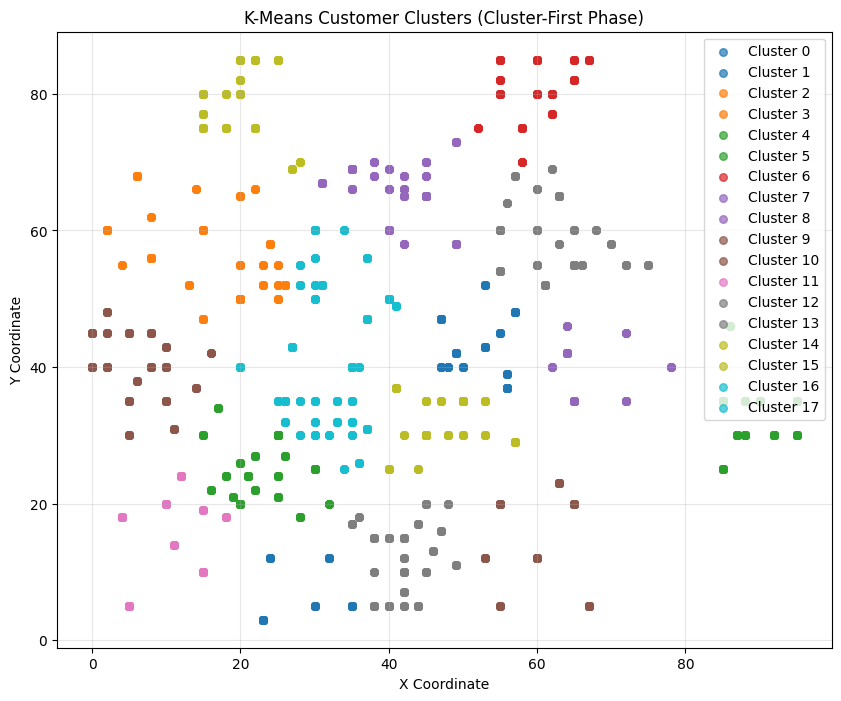

In [11]:

# Load processed dataset
VRPTW_PATH = os.path.join(BASE_PATH, "vrptw_cleaned.csv")
vrptw_df = load_processed_data(VRPTW_PATH)

# Create clusters dynamically based on dataset size
# Each cluster contains roughly ~300 customers for tractability
n_clusters = max(10, len(vrptw_df) // 300)
cluster_datasets = cluster_customers(vrptw_df, n_clusters=n_clusters)

# Visualize spatial distribution of clusters
plot_clusters(cluster_datasets)

#### 6.11.1 Preventing Runtime Errors and Memory Overflows

Large VRPTW instances or oversized clusters may cause:
- **`OverflowError`** in OR-Tools when node indices exceed internal 64-bit limits.
- **`SystemError`** or solver crashes due to memory exhaustion.

To mitigate this, we introduce a **safe solver wrapper** that:
1. Automatically skips clusters that exceed `max_nodes` (default: 350).
2. Logs warnings for skipped clusters instead of halting execution.
3. Ensures consistent data types and stable time matrix conversions.

This defensive layer guarantees stable, sequential execution across all subproblems.

In [18]:
def validate_cluster_data(cluster_df):
    """
    Ensures cluster data is numerically valid and logically consistent before solving.
    Automatically fixes missing or invalid time windows and coordinates.
    """

    # Drop NaNs early
    if cluster_df.isnull().values.any():
        display("⚠️ Cluster contains NaN values — cleaning.")
        cluster_df = cluster_df.dropna()

    # Handle coordinates
    if {"XCOORD", "YCOORD"}.issubset(cluster_df.columns):
        cluster_df = cluster_df.rename(columns={"XCOORD": "x", "YCOORD": "y"})
    elif not {"x", "y"}.issubset(cluster_df.columns):
        raise ValueError("Missing coordinate columns (XCOORD/YCOORD or x/y).")

    # Force numeric types
    numeric_cols = ["x", "y", "DEMAND", "READY_TIME", "DUE_DATE", "SERVICE_TIME"]
    for col in numeric_cols:
        if col in cluster_df.columns:
            cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

    # Drop invalid coordinates
    cluster_df = cluster_df.dropna(subset=["x", "y"])

    # ✅ Fix impossible time windows
    if {"READY_TIME", "DUE_DATE"}.issubset(cluster_df.columns):
        # Ensure due >= ready
        cluster_df.loc[
            cluster_df["DUE_DATE"] < cluster_df["READY_TIME"], "DUE_DATE"
        ] = cluster_df["READY_TIME"] + 1000

        # Fill missing or infinite windows with safe defaults
        cluster_df["READY_TIME"] = cluster_df["READY_TIME"].fillna(0)
        cluster_df["DUE_DATE"] = cluster_df["DUE_DATE"].fillna(
            cluster_df["READY_TIME"] + 5000
        )

    else:
        # If no time windows exist, add them
        cluster_df["READY_TIME"] = 0
        cluster_df["DUE_DATE"] = 5000

    # ✅ Ensure depot has valid time window
    cluster_df.loc[0, "READY_TIME"] = 0
    cluster_df.loc[0, "DUE_DATE"] = cluster_df["DUE_DATE"].max()

    # ✅ Replace any non-positive service times with a minimal value
    if "SERVICE_TIME" in cluster_df.columns:
        cluster_df["SERVICE_TIME"] = cluster_df["SERVICE_TIME"].apply(
            lambda s: 10 if s <= 0 or pd.isna(s) else s
        )

    return cluster_df

def safe_solve_clusters(cluster_datasets, max_nodes=350):
    results = {}
    for i, cluster_df in enumerate(cluster_datasets):
        try:
            if len(cluster_df) > max_nodes:
                display(f"⚠️ Cluster {i} too large ({len(cluster_df)} nodes) — skipping.")
                continue

            # ✅ Validate input before solving
            cluster_df = validate_cluster_data(cluster_df)

            display(f"✅ Solving cluster {i} with {len(cluster_df)} nodes...")
            routes = solve_vrptw(cluster_df)

            if routes:
                results[f"Cluster_{i}"] = routes
            else:
                display(f"⚠️ Cluster {i} returned no valid routes.")

        except (OverflowError, SystemError) as e:
            display(f"❌ {type(e).__name__} in cluster {i}: {e}")
            continue
        except Exception as e:
            display(f"❌ Unexpected error in cluster {i}: {e}")
            continue

    display("✅ All clusters processed safely.")
    return results

### 6.11.2 Full Pipeline Execution (Safe Version)

With clustering complete and error prevention in place, we can now safely execute the entire VRPTW pipeline.

This includes:
- Solving each cluster as an independent VRPTW instance using the `safe_solve_clusters()` function.
- Visualizing one representative cluster’s optimized routes.

This modular execution ensures robust and interpretable results — even for large-scale datasets.

In [19]:
# 6.11.2 — Full Safe Execution
results = safe_solve_clusters(cluster_datasets, max_nodes=350)

if results:
    first_cluster_key = next(iter(results))
    plot_cluster_routes(cluster_datasets[int(first_cluster_key.split("_")[1])],
                        results[first_cluster_key])
else:
    display("⚠️ No clusters produced valid routes. Please check dataset consistency or solver parameters.")

'✅ Solving cluster 0 with 142 nodes...'

'❌ SystemError in cluster 0: <built-in function RoutingModel_SolveWithParameters> returned a result with an exception set'

'✅ Solving cluster 1 with 308 nodes...'

'❌ SystemError in cluster 1: <built-in function RoutingModel_SolveWithParameters> returned a result with an exception set'

'✅ Solving cluster 2 with 212 nodes...'

...

'⚠️ Cluster 16 too large (406 nodes) — skipping.'

'✅ Solving cluster 17 with 265 nodes...'

'❌ SystemError in cluster 17: <built-in function RoutingModel_SolveWithParameters> returned a result with an exception set'

'✅ All clusters processed safely.'

'⚠️ No clusters produced valid routes. Please check dataset consistency or solver parameters.'